# Analisi dei risultati della simulazione phishing

Questo notebook analizza i CSV generati da `simulations/run_simulation.py`.

L'obiettivo non è stimare il comportamento reale della popolazione, ma confrontare in modo controllato come agenti sintetici con profili diversi reagiscono a scenari di phishing e messaggi legittimi.

Il notebook distingue tra:

- **click / interazione iniziale**: l'agente apre un link o mostra interesse;
- **compromissione stretta**: l'agente inserisce credenziali o seed phrase;
- **segnalazione**: l'agente riconosce il messaggio come sospetto;
- **falso positivo**: l'agente segnala come phishing un messaggio legittimo.


In [20]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

RESULTS_DIR = Path("results")
PLOTS_DIR = RESULTS_DIR / "plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", None)


## 1. Caricamento del dataset

Il codice carica automaticamente il CSV più recente nella cartella `results/`.

Se vuoi analizzare un file specifico, sostituisci `csv_path` con il percorso desiderato.


In [21]:
csv_files = sorted(RESULTS_DIR.glob("sim_*.csv"))

if not csv_files:
    raise FileNotFoundError(
        "Nessun file sim_*.csv trovato in results/. "
        "Esegui prima: python simulations/run_simulation.py"
    )

csv_path = csv_files[-1]
print(f"File caricato: {csv_path}")

df = pd.read_csv(csv_path)
df.head()


File caricato: results\sim_20260508_114100.csv


,agent_id,age,age_group,role,crypto_experience,security_training,environment,message_id,message_type,channel,scenario_description,urgency,personalization,reward,choice,motivation
0,teen_gamer_lowsec_1,15,15-20,studente_scuola_superiore,bassa,no,uso_social_gaming,exchange_kyc_urgente,phishing,email,Finta mail dell'exchange che minaccia blocco c...,alta,bassa,nessuno,CLICCA_SUL_LINK,"Non penso che sia un problema, è probabilmente..."
1,teen_gamer_lowsec_1,15,15-20,studente_scuola_superiore,bassa,no,uso_social_gaming,defi_airdrop_premio,phishing,social,Airdrop DeFi con APY molto elevati,media,bassa,altissimo,CLICCA_SUL_LINK,"Sono un teenager e mi piace il sociale, mi sem..."
2,teen_gamer_lowsec_1,15,15-20,studente_scuola_superiore,bassa,no,uso_social_gaming,supporto_tecnico_seed,phishing,chat,Finto supporto tecnico che chiede seed phrase,alta,media,nessuno,5,Il messaggio sembra troppo 'off' per essere ge...
3,teen_gamer_lowsec_1,15,15-20,studente_scuola_superiore,bassa,no,uso_social_gaming,discord_moderatore_rugpull,phishing,chat,Finto moderatore Discord che invia link a dApp...,bassa,alta,alta,CLICCA_SUL_LINK,Sono attirato dalla promessa di un bonus del 5...
4,teen_gamer_lowsec_1,15,15-20,studente_scuola_superiore,bassa,no,uso_social_gaming,twitter_giveaway_match,phishing,social,"Giveaway su social con schema 'inviami 1 ETH, ...",alta,bassa,altissimo,CLICK_SUL_LINK,Sono un grande fan di CryptoInfluencerXYZ e no...


## 2. Normalizzazione e controlli preliminari

Questa sezione rende il notebook compatibile sia con i CSV vecchi sia con quelli nuovi.

In particolare:

- normalizza `legitimo` in `legittimo`;
- normalizza scelte come `2`, `2) CLICCA_SUL_LINK`, `CLICK_SUL_LINK`;
- gestisce eventuali `PARSE_ERROR`;
- aggiunge colonne mancanti nei CSV generati da versioni precedenti dello script.


In [22]:
CHOICE_MAPPING = {
    "1": "IGNORA",
    "1) IGNORA": "IGNORA",
    "2": "CLICCA_SUL_LINK",
    "2) CLICCA_SUL_LINK": "CLICCA_SUL_LINK",
    "CLICK_SUL_LINK": "CLICCA_SUL_LINK",
    "CLICKA_SUL_LINK": "CLICCA_SUL_LINK",
    "3": "INSERISCI_CREDENZIALI",
    "3) INSERISCI_CREDENZIALI": "INSERISCI_CREDENZIALI",
    "4": "CHIEDI_AIUTO_AMICO",
    "4) CHIEDI_AIUTO_AMICO": "CHIEDI_AIUTO_AMICO",
    "5": "SEGNALA_COME_PHISHING",
    "5) SEGNALA_COME_PHISHING": "SEGNALA_COME_PHISHING",
}

ALLOWED_CHOICES = {
    "IGNORA",
    "CLICCA_SUL_LINK",
    "INSERISCI_CREDENZIALI",
    "CHIEDI_AIUTO_AMICO",
    "SEGNALA_COME_PHISHING",
    "PARSE_ERROR",
}

# Colonne introdotte nelle versioni più recenti dello script
if "raw_choice" not in df.columns:
    df["raw_choice"] = df["choice"]

if "parse_error" not in df.columns:
    # Nei CSV vecchi gli errori di parsing finivano spesso in IGNORA con motivazione di fallback
    fallback_mask = df.get("motivation", "").astype(str).str.contains(
        "fallback|errore parsing|errore di parsing", case=False, na=False
    )
    df["parse_error"] = fallback_mask

if "run_id" not in df.columns:
    df["run_id"] = csv_path.stem.replace("sim_", "")

if "model" not in df.columns:
    df["model"] = "unknown"

# Normalizza tipi messaggio
if "message_type" in df.columns:
    df["message_type"] = df["message_type"].replace({
        "legitimo": "legittimo",
        "legitimate": "legittimo",
        "legittima": "legittimo",
    })

# Normalizza scelte
normalized = (
    df["choice"]
    .astype(str)
    .str.strip()
    .str.upper()
)

df["choice_normalized"] = normalized.map(lambda x: CHOICE_MAPPING.get(x, x))
df.loc[~df["choice_normalized"].isin(ALLOWED_CHOICES), "choice_normalized"] = "PARSE_ERROR"

# Se lo script nuovo ha già segnato parse_error, manteniamo quell'informazione
if df["parse_error"].dtype == object:
    df["parse_error"] = df["parse_error"].astype(str).str.lower().isin(["true", "1", "yes"])

df.loc[df["choice_normalized"] == "PARSE_ERROR", "parse_error"] = True

valid_df = df[~df["parse_error"]].copy()
phishing_df = valid_df[valid_df["message_type"] == "phishing"].copy()
legit_df = valid_df[valid_df["message_type"] == "legittimo"].copy()

summary = pd.DataFrame({
    "metrica": [
        "righe totali",
        "righe valide",
        "parse error",
        "agenti unici",
        "messaggi unici",
        "messaggi phishing validi",
        "messaggi legittimi validi",
    ],
    "valore": [
        len(df),
        len(valid_df),
        int(df["parse_error"].sum()),
        df["agent_id"].nunique() if "agent_id" in df.columns else None,
        df["message_id"].nunique() if "message_id" in df.columns else None,
        len(phishing_df),
        len(legit_df),
    ]
})

summary


,metrica,valore
0,righe totali,720
1,righe valide,677
2,parse error,43
3,agenti unici,90
4,messaggi unici,8
5,messaggi phishing validi,513
6,messaggi legittimi validi,164


## 3. Distribuzione globale delle scelte

Questa tabella serve a capire il comportamento complessivo degli agenti, ma non distingue ancora tra phishing e messaggi legittimi.


In [23]:
choice_distribution = (
    valid_df["choice_normalized"]
    .value_counts()
    .rename_axis("choice")
    .reset_index(name="count")
)
choice_distribution["percentage"] = choice_distribution["count"] / choice_distribution["count"].sum() * 100
choice_distribution


,choice,count,percentage
0,CLICCA_SUL_LINK,388,57.311669
1,SEGNALA_COME_PHISHING,240,35.450517
2,IGNORA,37,5.465288
3,CHIEDI_AIUTO_AMICO,8,1.181684
4,INSERISCI_CREDENZIALI,4,0.590842


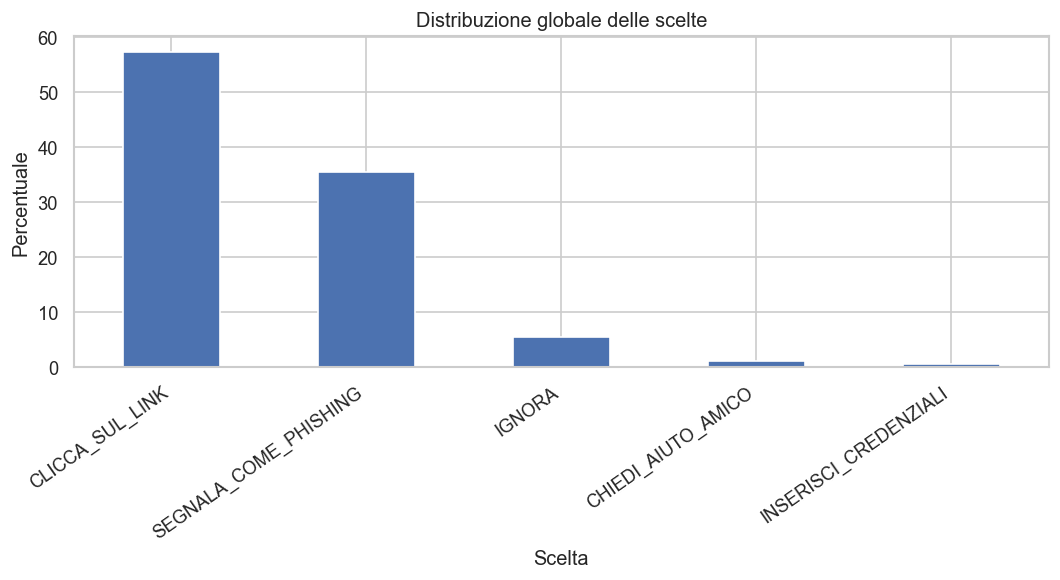

In [24]:
ax = choice_distribution.plot(
    kind="bar",
    x="choice",
    y="percentage",
    legend=False,
    figsize=(9, 5),
)
ax.set_title("Distribuzione globale delle scelte")
ax.set_xlabel("Scelta")
ax.set_ylabel("Percentuale")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "global_choice_distribution.png", dpi=200)
plt.show()


## 4. Metriche corrette per i messaggi di phishing

Per i messaggi di phishing, distinguiamo:

- **click rate**: l'agente apre il link;
- **compromissione stretta**: l'agente inserisce credenziali o seed phrase;
- **failure loose**: l'agente compie una qualunque azione rischiosa, includendo il click;
- **reporting rate**: l'agente segnala il messaggio come phishing.

Il click non equivale automaticamente a compromissione: indica solo una prima interazione rischiosa.


In [25]:
if phishing_df.empty:
    raise ValueError("Nessun messaggio phishing valido trovato nel dataset.")

phishing_df["click_rate"] = phishing_df["choice_normalized"] == "CLICCA_SUL_LINK"
phishing_df["credential_disclosure"] = phishing_df["choice_normalized"] == "INSERISCI_CREDENZIALI"
phishing_df["failure_loose"] = phishing_df["choice_normalized"].isin([
    "CLICCA_SUL_LINK",
    "INSERISCI_CREDENZIALI",
])
phishing_df["reporting_rate"] = phishing_df["choice_normalized"] == "SEGNALA_COME_PHISHING"
phishing_df["ignore_rate"] = phishing_df["choice_normalized"] == "IGNORA"
phishing_df["help_rate"] = phishing_df["choice_normalized"] == "CHIEDI_AIUTO_AMICO"

phishing_metrics = pd.DataFrame({
    "metrica": [
        "click rate",
        "credential/seed disclosure rate",
        "failure loose rate",
        "reporting rate",
        "ignore rate",
        "help-seeking rate",
    ],
    "percentuale": [
        phishing_df["click_rate"].mean() * 100,
        phishing_df["credential_disclosure"].mean() * 100,
        phishing_df["failure_loose"].mean() * 100,
        phishing_df["reporting_rate"].mean() * 100,
        phishing_df["ignore_rate"].mean() * 100,
        phishing_df["help_rate"].mean() * 100,
    ]
})

phishing_metrics


,metrica,percentuale
0,click rate,53.801170
1,credential/seed disclosure rate,0.779727
2,failure loose rate,54.580897
3,reporting rate,40.545809
4,ignore rate,3.313840
5,help-seeking rate,1.559454


## 5. Metriche per i messaggi legittimi

Per i messaggi legittimi non ha senso parlare di compromissione se l'agente clicca.

In questo caso misuriamo soprattutto:

- **legitimate click rate**: l'agente interagisce con un messaggio legittimo;
- **false positive rate**: l'agente segnala come phishing un messaggio legittimo.


In [26]:
if legit_df.empty:
    print("Nessun messaggio legittimo valido trovato nel dataset.")
    legit_metrics = pd.DataFrame(columns=["metrica", "percentuale"])
else:
    legit_df["legitimate_click_rate"] = legit_df["choice_normalized"] == "CLICCA_SUL_LINK"
    legit_df["false_positive_rate"] = legit_df["choice_normalized"] == "SEGNALA_COME_PHISHING"
    legit_df["ignore_rate"] = legit_df["choice_normalized"] == "IGNORA"

    legit_metrics = pd.DataFrame({
        "metrica": [
            "legitimate click rate",
            "false positive rate",
            "ignore rate",
        ],
        "percentuale": [
            legit_df["legitimate_click_rate"].mean() * 100,
            legit_df["false_positive_rate"].mean() * 100,
            legit_df["ignore_rate"].mean() * 100,
        ]
    })

legit_metrics


,metrica,percentuale
0,legitimate click rate,68.292683
1,false positive rate,19.512195
2,ignore rate,12.195122


## 6. Risultati per scenario

Questa tabella mostra quali scenari generano più interazioni rischiose e quali vengono riconosciuti più spesso come phishing.


In [27]:
by_message = (
    phishing_df
    .groupby(["message_id", "scenario_description"], dropna=False)
    .agg(
        n=("choice_normalized", "size"),
        click_rate=("click_rate", "mean"),
        credential_disclosure=("credential_disclosure", "mean"),
        failure_loose=("failure_loose", "mean"),
        reporting_rate=("reporting_rate", "mean"),
        ignore_rate=("ignore_rate", "mean"),
    )
    .reset_index()
)

percentage_cols = ["click_rate", "credential_disclosure", "failure_loose", "reporting_rate", "ignore_rate"]
by_message[percentage_cols] = by_message[percentage_cols] * 100
by_message = by_message.sort_values("failure_loose", ascending=False)
by_message


,message_id,scenario_description,n,click_rate,credential_disclosure,failure_loose,reporting_rate,ignore_rate
5,update_app_store_falso,Notifica push che invita a scaricare una falsa...,88,92.045455,0.000000,92.045455,0.000000,6.818182
0,defi_airdrop_premio,Airdrop DeFi con APY molto elevati,88,65.909091,0.000000,65.909091,31.818182,2.272727
1,discord_moderatore_rugpull,Finto moderatore Discord che invia link a dApp...,85,65.882353,0.000000,65.882353,22.352941,4.705882
2,exchange_kyc_urgente,Finta mail dell'exchange che minaccia blocco c...,86,62.790698,1.162791,63.953488,29.069767,5.813953
4,twitter_giveaway_match,"Giveaway su social con schema 'inviami 1 ETH, ...",79,30.379747,0.000000,30.379747,69.620253,0.000000
3,supporto_tecnico_seed,Finto supporto tecnico che chiede seed phrase,87,3.448276,3.448276,6.896552,93.103448,0.000000


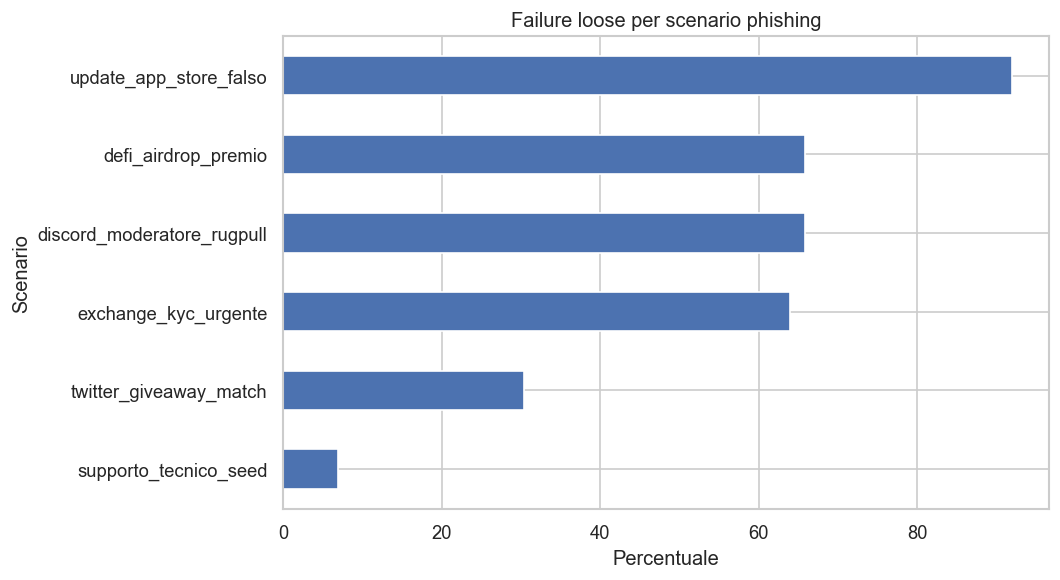

In [28]:
plot_df = by_message.sort_values("failure_loose", ascending=True)
ax = plot_df.plot(
    kind="barh",
    x="message_id",
    y="failure_loose",
    legend=False,
    figsize=(9, 5),
)
ax.set_title("Failure loose per scenario phishing")
ax.set_xlabel("Percentuale")
ax.set_ylabel("Scenario")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "failure_loose_by_message.png", dpi=200)
plt.show()


## 7. Risultati per livello di formazione

Questa sezione confronta gli agenti in base alla formazione dichiarata nel profilo.


In [29]:
by_training = (
    phishing_df
    .groupby("security_training", dropna=False)
    .agg(
        n=("choice_normalized", "size"),
        click_rate=("click_rate", "mean"),
        credential_disclosure=("credential_disclosure", "mean"),
        failure_loose=("failure_loose", "mean"),
        reporting_rate=("reporting_rate", "mean"),
        ignore_rate=("ignore_rate", "mean"),
    )
    .reset_index()
)
by_training[percentage_cols] = by_training[percentage_cols] * 100
by_training = by_training.sort_values("failure_loose", ascending=False)
by_training


,security_training,n,click_rate,credential_disclosure,failure_loose,reporting_rate,ignore_rate
3,no,176,82.386364,1.704545,84.090909,15.909091,0.000000
0,autodidatta,68,64.705882,0.000000,64.705882,35.294118,0.000000
1,basilare,104,47.115385,0.000000,47.115385,48.076923,3.846154
2,minima,36,33.333333,0.000000,33.333333,33.333333,33.333333
4,si,129,20.155039,0.775194,20.930233,72.868217,0.775194


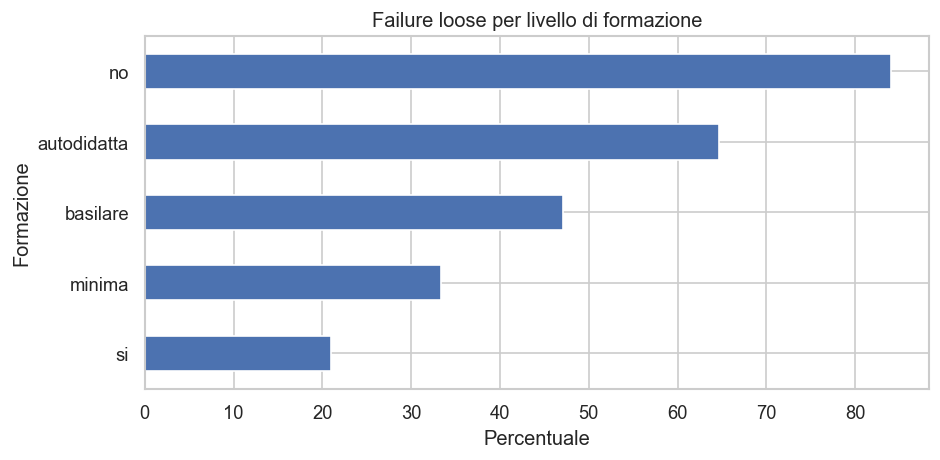

In [30]:
plot_df = by_training.sort_values("failure_loose", ascending=True)
ax = plot_df.plot(
    kind="barh",
    x="security_training",
    y="failure_loose",
    legend=False,
    figsize=(8, 4),
)
ax.set_title("Failure loose per livello di formazione")
ax.set_xlabel("Percentuale")
ax.set_ylabel("Formazione")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "failure_loose_by_training.png", dpi=200)
plt.show()


## 8. Risultati per fascia d'età

Questa analisi è esplorativa: le fasce d'età degli agenti non rappresentano un campione statistico della popolazione reale.


In [31]:
by_age = (
    phishing_df
    .groupby("age_group", dropna=False)
    .agg(
        n=("choice_normalized", "size"),
        click_rate=("click_rate", "mean"),
        credential_disclosure=("credential_disclosure", "mean"),
        failure_loose=("failure_loose", "mean"),
        reporting_rate=("reporting_rate", "mean"),
        ignore_rate=("ignore_rate", "mean"),
    )
    .reset_index()
)
by_age[percentage_cols] = by_age[percentage_cols] * 100
by_age = by_age.sort_values("age_group")
by_age


,age_group,n,click_rate,credential_disclosure,failure_loose,reporting_rate,ignore_rate
0,15-20,34,85.294118,0.000000,85.294118,14.705882,0.000000
1,21-25,100,50.000000,0.000000,50.000000,50.000000,0.000000
2,26-30,106,56.603774,0.000000,56.603774,32.075472,11.320755
3,31-45,168,48.809524,2.380952,51.190476,44.047619,0.595238
4,46-60,36,66.666667,0.000000,66.666667,33.333333,0.000000
5,60+,69,44.927536,0.000000,44.927536,47.826087,5.797101


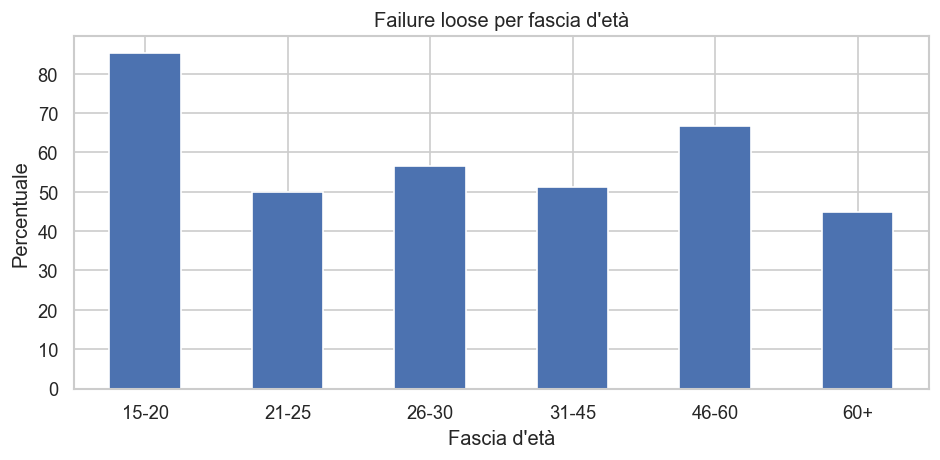

In [32]:
ax = by_age.plot(
    kind="bar",
    x="age_group",
    y="failure_loose",
    legend=False,
    figsize=(8, 4),
)
ax.set_title("Failure loose per fascia d'età")
ax.set_xlabel("Fascia d'età")
ax.set_ylabel("Percentuale")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "failure_loose_by_age_group.png", dpi=200)
plt.show()


## 9. Falsi positivi sui messaggi legittimi

Questa sezione serve a misurare se gli agenti tendono a essere eccessivamente sospettosi.


In [33]:
if legit_df.empty:
    by_legit_message = pd.DataFrame()
else:
    by_legit_message = (
        legit_df
        .groupby(["message_id", "scenario_description"], dropna=False)
        .agg(
            n=("choice_normalized", "size"),
            legitimate_click_rate=("legitimate_click_rate", "mean"),
            false_positive_rate=("false_positive_rate", "mean"),
            ignore_rate=("ignore_rate", "mean"),
        )
        .reset_index()
    )
    by_legit_message[["legitimate_click_rate", "false_positive_rate", "ignore_rate"]] *= 100

by_legit_message


,message_id,scenario_description,n,legitimate_click_rate,false_positive_rate,ignore_rate
0,exchange_legit_password_reset,Mail legittima di reset password (controllo),78,60.256410,26.923077,12.820513
1,newsletter_legit_sicurezza,Newsletter educativa sulla sicurezza (controllo),86,75.581395,12.790698,11.627907


## 10. Esportazione tabelle

Le tabelle principali vengono salvate in `results/plots/` per poterle usare nella tesi.


In [34]:
choice_distribution.to_csv(PLOTS_DIR / "table_choice_distribution.csv", index=False)
phishing_metrics.to_csv(PLOTS_DIR / "table_phishing_metrics.csv", index=False)
legit_metrics.to_csv(PLOTS_DIR / "table_legitimate_metrics.csv", index=False)
by_message.to_csv(PLOTS_DIR / "table_phishing_by_message.csv", index=False)
by_training.to_csv(PLOTS_DIR / "table_phishing_by_training.csv", index=False)
by_age.to_csv(PLOTS_DIR / "table_phishing_by_age_group.csv", index=False)

if not by_legit_message.empty:
    by_legit_message.to_csv(PLOTS_DIR / "table_legitimate_by_message.csv", index=False)

print(f"Tabelle e grafici salvati in: {PLOTS_DIR}")


Tabelle e grafici salvati in: results\plots


## 11. Interpretazione metodologica

I risultati devono essere letti come output di una simulazione controllata, non come misurazioni statistiche su persone reali.

In particolare:

- un click rappresenta una prima interazione rischiosa, ma non implica automaticamente furto di credenziali o perdita di fondi;
- la compromissione stretta è associata ad azioni più gravi, come inserire credenziali o seed phrase;
- i messaggi legittimi vanno analizzati separatamente, perché un click su un messaggio legittimo non è una compromissione;
- i valori percentuali servono soprattutto a confrontare scenari e profili tra loro, non a stimare la vulnerabilità reale della popolazione.

Una formulazione adatta alla tesi può essere:

> I risultati ottenuti non devono essere interpretati come una stima statistica del comportamento umano reale. Gli agenti sintetici non costituiscono un campione rappresentativo di utenti, ma permettono di osservare in modo controllato come differenti profili e caratteristiche del messaggio possano influenzare la propensione all'interazione con contenuti fraudolenti. Il valore dell'esperimento è quindi principalmente comparativo ed esplorativo.
